# U6 — Probability & Statistics (Part 2): Lab

**Probability & Information Theory** — axioms · conditional probability · Bayes · distributions · entropy · KL divergence & mutual information

_Day 3 · Phase B — Mathematical Foundations · Built from Module 1.4 + 2.2 (finishing U6)_

#1. Probability theory & axioms

In [3]:
# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [4]:
import numpy as np

# -----------------------------------------------------------
# 🔹 1A. PROBABILITY BY SIMULATION
# -----------------------------------------------------------

# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [5]:
# -----------------------------------------------------------
# 🔹 1B. THE ADDITION RULE (disjoint events)
# -----------------------------------------------------------

# Rolling a 1 OR a 2 — these events can't both happen (disjoint)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [20]:
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)

# 1. P(both heads) -> heads == 2
p_both_heads = (heads == 2).mean()
print("P(both heads) =", round(p_both_heads, 3))

# 2. P(at least one head) -> heads >= 1
p_at_least_one = (heads >= 1).mean()
print("P(at least one head) =", round(p_at_least_one, 3))

# 3. Do P(0) + P(1) + P(2) sum to 1?
p_0 = (heads == 0).mean()
p_1 = (heads == 1).mean()
p_2 = (heads == 2).mean()

print("P(0) + P(1) + P(2) =", round(p_0 + p_1 + p_2, 3))

P(both heads) = 0.25
P(at least one head) = 0.75
P(0) + P(1) + P(2) = 1.0


#2. Conditional probability & independence

In [8]:
# -----------------------------------------------------------
# 🔹 2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)
# -----------------------------------------------------------

rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [7]:
# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.5
P(A | B)  = 0.665
Independent? False


In [9]:
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)
less_than_4 = rolls[rolls < 4]
p_odd_given_less4 = (less_than_4 % 2 == 1).mean()

print("P(odd | roll < 4) =", round(p_odd_given_less4, 3))

# 2. P(roll < 4)
p_less4 = (rolls < 4).mean()

print("P(roll < 4) =", round(p_less4, 3))

# 3. P(odd) overall
p_odd = (rolls % 2 == 1).mean()

print("P(odd) =", round(p_odd, 3))

# Check independence
print("Independent?", np.isclose(p_odd_given_less4, p_odd, atol=0.02))

P(odd | roll < 4) = 0.668
P(roll < 4) = 0.503
P(odd) = 0.503
Independent? False


#3. Bayes' theorem

**P(A | B) = P(B | A) · P(A) / P(B)** — update your belief in A after seeing evidence B.

In [10]:
# -----------------------------------------------------------
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
# -----------------------------------------------------------

# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [11]:
# -----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.502


In [12]:
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham = 0.05

# 2. P("free") using total probability
p_free = (p_free_given_spam * p_spam) + \
         (p_free_given_ham * (1 - p_spam))

print("P('free') =", round(p_free, 3))

# 3. Bayes: P(spam | "free")
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print("P(spam | 'free') =", round(p_spam_given_free, 3))

P('free') = 0.16
P(spam | 'free') = 0.75


#4. Probability distributions

In [13]:
# -----------------------------------------------------------
# 🔹 4A. BERNOULLI & POISSON (discrete)
# -----------------------------------------------------------

# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.295 (true 0.3)
Poisson(4) mean ~ 3.965 (true 4)


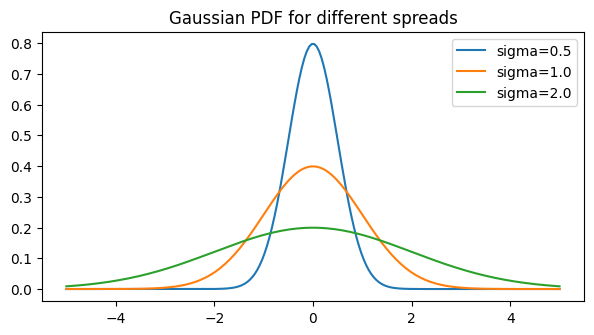

In [14]:
# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Poisson sample mean = 2.016


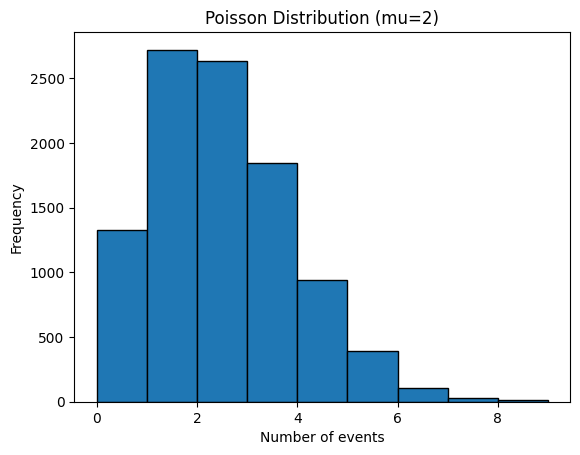

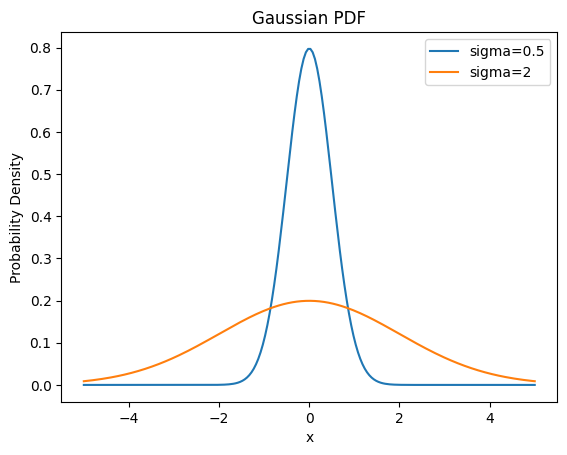

In [15]:
# 1. Poisson(mu=2) samples + mean
pois = stats.poisson(mu=2).rvs(size=10_000)

print("Poisson sample mean =", round(pois.mean(), 3))


# 2. Histogram of Poisson samples
plt.hist(pois, bins=range(0, 10), edgecolor='black')
plt.title("Poisson Distribution (mu=2)")
plt.xlabel("Number of events")
plt.ylabel("Frequency")
plt.show()


# 3. Gaussian PDF for two sigmas
x = np.linspace(-5, 5, 200)

plt.plot(x, stats.norm(0, 0.5).pdf(x), label="sigma=0.5")
plt.plot(x, stats.norm(0, 2).pdf(x), label="sigma=2")

plt.title("Gaussian PDF")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

#5. Entropy, KL divergence & mutual information

In [16]:
# -----------------------------------------------------------
# 🔹 5A. ENTROPY — how uncertain is a distribution?
# -----------------------------------------------------------

from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [17]:
# -----------------------------------------------------------
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
# -----------------------------------------------------------

P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [18]:
# -----------------------------------------------------------
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [19]:
# 1. Entropy of fair 4-sided and 6-sided dice

die4 = [1/4] * 4
die6 = [1/6] * 6

entropy4 = entropy(die4, base=2)
entropy6 = entropy(die6, base=2)

print("Entropy of 4-sided die =", round(entropy4, 3), "bits")
print("Entropy of 6-sided die =", round(entropy6, 3), "bits")

if entropy6 > entropy4:
    print("6-sided die is more uncertain")
else:
    print("4-sided die is more uncertain")

Entropy of 4-sided die = 2.0 bits
Entropy of 6-sided die = 2.585 bits
6-sided die is more uncertain
